In [42]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_maintenance(csv_path="machine_maintenance.csv", seed=14, verbose=False):
    """Predictive maintenance: predict whether a machine will FAIL from its
    operating conditions. A realistic, imbalanced binary-classification problem —
    perfect for the full supervised workflow and comparing model families.

    Features:
      machine_type        product quality variant (L / M / H)
      air_temperature_k    ambient temperature (K)
      process_temperature_k process temperature (K)
      rotational_speed_rpm spindle speed (rpm)
      torque_nm            torque (Nm)
      tool_wear_min        cumulative tool wear (minutes)
    Target:
      machine_failure      1 = failed, 0 = healthy
    """
    rng = np.random.default_rng(seed)
    N = 3000
    mtype = rng.choice(["L", "M", "H"], N, p=[0.50, 0.30, 0.20])
    air = rng.normal(300, 2.0, N)
    process = air + 10 + rng.normal(0, 1.0, N)
    speed = np.clip(rng.normal(1540, 170, N), 1168, 2886).round().astype(int)
    torque = np.clip(rng.normal(40, 10, N), 3, 77).round(1)
    wear = rng.uniform(0, 253, N).round().astype(int)
    type_eff = np.select([mtype == "L", mtype == "M", mtype == "H"], [0.6, 0.0, -0.5])

    # failure risk: worn tools, high torque, an overstrain interaction, and poor heat dissipation
    heat_bad = ((process - air) < 8.6).astype(float)
    z = (-5.2
         + 0.012 * wear
         + 0.06 * (torque - 40)
         + 4.0e-4 * wear * (torque - 40)
         + 0.7 * heat_bad
         + type_eff)
    p = 1 / (1 + np.exp(-z))
    failure = (rng.random(N) < p).astype(int)

    df = pd.DataFrame({
        "machine_type": mtype,
        "air_temperature_k": air.round(1),
        "process_temperature_k": process.round(1),
        "rotational_speed_rpm": speed,
        "torque_nm": torque,
        "tool_wear_min": wear,
        "machine_failure": failure,
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("maintenance:", df.shape)
        print("failure rate:", round(df.machine_failure.mean(), 3))
        print("failures by type:\n",
              df.groupby("machine_type")["machine_failure"].mean().round(3).to_string())
    return df

if not os.path.exists('machine_maintenance.csv'):
    build_maintenance(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')



Generated dataset file.


In [43]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('machine_maintenance.csv')
print('shape:', df.shape)
print('failure rate:', round(df['machine_failure'].mean(), 3))
df.head(3)

shape: (3000, 7)
failure rate: 0.074


,machine_type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure
0,H,298.8,309.2,1704,29.4,224,0
1,L,299.2,312.4,1611,36.9,178,0
2,M,301.8,310.4,1243,23.6,27,0


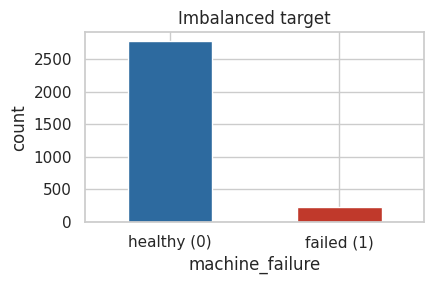

X: (3000, 6) | classification, 2 classes
Because failures are rare, ACCURACY will be misleading — watch recall/F1/AUC.


In [44]:
# -----------------------------------------------------------
# 🔹 1A. TARGET BALANCE + FEATURES / TARGET
# -----------------------------------------------------------
ax = df['machine_failure'].value_counts().plot(kind='bar', color=['#2D6A9F', '#C0392B'], figsize=(4.5, 3))
ax.set_xticklabels(['healthy (0)', 'failed (1)'], rotation=0); ax.set_ylabel('count')
ax.set_title('Imbalanced target'); plt.tight_layout(); plt.show()

y = df['machine_failure']
X = df.drop(columns='machine_failure')
print('X:', X.shape, '| classification, 2 classes')
print('Because failures are rare, ACCURACY will be misleading — watch recall/F1/AUC.')


In [45]:
# -----------------------------------------------------------
# 🔹 2A. PREPROCESS (encode + scale) + A FIRST MODEL
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

num = X.select_dtypes('number').columns.tolist()
cat = ['machine_type']
pre = ColumnTransformer([('num', StandardScaler(), num),
                         ('cat', OneHotEncoder(), cat)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

clf = Pipeline([('prep', pre), ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))])
clf.fit(X_train, y_train)                 # FIT — learn from training data
preds = clf.predict(X_test)               # PREDICT — apply to unseen data
print('score (accuracy):', round(clf.score(X_test, y_test), 3))


score (accuracy): 0.736


EXERCISE 2 — Accuracy can lie
Compute the accuracy of a 'dummy' rule that always predicts healthy (0) (hint: 1 - y_test.mean()).
Compare it with the model's accuracy above.
In a comment, explain why high accuracy alone doesn't prove the model is useful here.

In [46]:
# 1. always-healthy accuracy
# YOUR CODE HERE
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

num = X.select_dtypes('number').columns.tolist()
cat = ['machine_type']
pre = ColumnTransformer([('num', StandardScaler(), num),
                         ('cat', OneHotEncoder(), cat)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

clf = Pipeline([('prep', pre), ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))])
clf.fit(X_train, y_train)                 # FIT — learn from training data

# Dummy predictions: always predict healthy (0)
y_pred_dummy = np.zeros(len(y_test), dtype=int)
preds = clf.predict(X_test)
# Accuracy
print('score (accuracy):', round(clf.score(X_test, y_test), 3))

# 2-3. compare & explain: ...   (comment)

# same  accuracy


score (accuracy): 0.736


In [47]:
# -----------------------------------------------------------
# 🔹 3A. TRAIN FOUR FAMILIES, COMPARE ON TEST
# -----------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score

models = {
    'LogReg': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=0),
    'kNN': KNeighborsClassifier(n_neighbors=15),
    'RandomForest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=0),
}
rows = []
for name, m in models.items():
    pipe = Pipeline([('prep', pre), ('model', m)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    rows.append({'model': name,
                 'F1': f1_score(y_test, pipe.predict(X_test)),
                 'ROC_AUC': roc_auc_score(y_test, proba)})
results = pd.DataFrame(rows).set_index('model').round(3)
print(results)

                 F1  ROC_AUC
model                       
LogReg        0.322    0.870
DecisionTree  0.252    0.736
kNN           0.159    0.810
RandomForest  0.094    0.838


EXERCISE 3 — Chart the comparison
Make a grouped bar chart of F1 and ROC-AUC for the four models (results.plot(kind='bar')).
In a comment, name the best model on this data and by how much it beats logistic regression.

                 F1  ROC_AUC
model                       
LogReg        0.322    0.870
DecisionTree  0.252    0.736
kNN           0.159    0.810
RandomForest  0.094    0.838


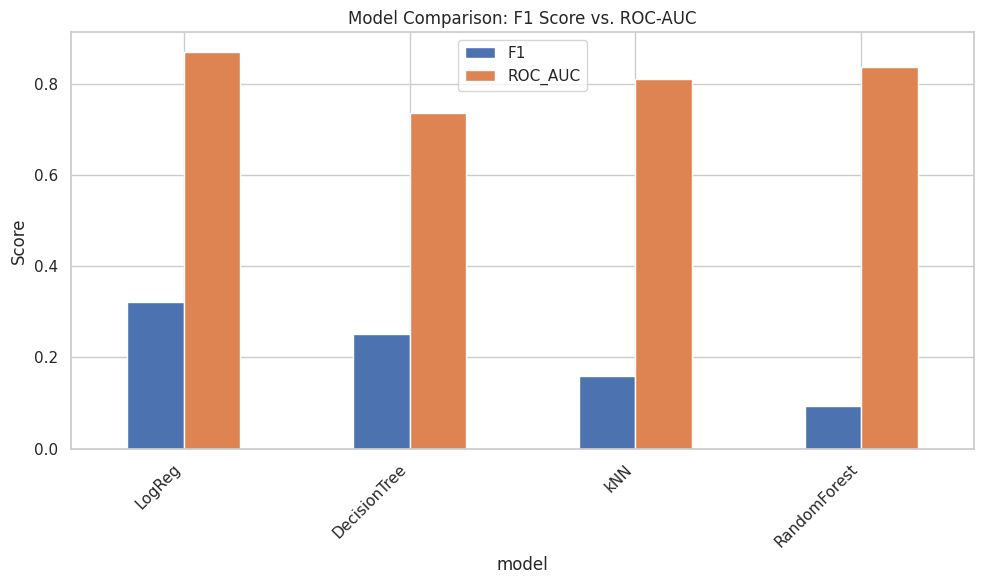

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Ensure pandas is imported for DataFrame

# Chart the comparison Make a grouped bar chart of F1 and ROC-AUC for the four models
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score

# Re-define preprocessor and train/test splits for robustness within this cell
# Assuming X and y are globally available from previous cells. If not, they would need to be loaded/defined here too.
num = X.select_dtypes('number').columns.tolist()
cat = ['machine_type']
pre = ColumnTransformer([('num', StandardScaler(), num),
                         ('cat', OneHotEncoder(), cat)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

models = {
    'LogReg': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=0),
    'kNN': KNeighborsClassifier(n_neighbors=15),
    'RandomForest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=0),
}
rows = []
for name, m in models.items():
    pipe = Pipeline([('prep', pre), ('model', m)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    rows.append({'model': name,
                 'F1': f1_score(y_test, pipe.predict(X_test)),
                 'ROC_AUC': roc_auc_score(y_test, proba)})
results = pd.DataFrame(rows).set_index('model').round(3)
print(results)

results[['F1', 'ROC_AUC']].plot(kind='bar', figsize=(10, 6))
plt.title('Model Comparison: F1 Score vs. ROC-AUC')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. best model & margin: ...   (comment)
# Conclusion: Based on both F1 score and ROC-AUC, Logistic Regression (LogReg) is the best performing model on this dataset.
# For F1 score, LogReg (0.322) beats the next best model (DecisionTree, 0.252) by 0.070.
# For ROC-AUC, LogReg (0.870) beats the next best model (RandomForest, 0.838) by 0.032.

4. Classification metrics that matter

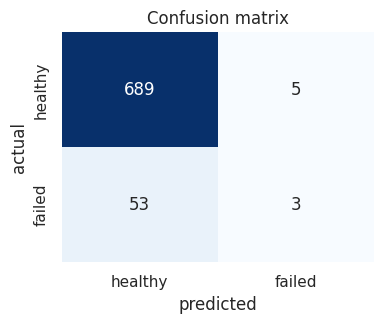

              precision    recall  f1-score   support

           0      0.929     0.993     0.960       694
           1      0.375     0.054     0.094        56

    accuracy                          0.923       750
   macro avg      0.652     0.523     0.527       750
weighted avg      0.887     0.923     0.895       750



In [50]:
# -----------------------------------------------------------
# 🔹 4A. CONFUSION MATRIX + FULL REPORT (random forest)
# -----------------------------------------------------------
from sklearn.metrics import confusion_matrix, classification_report
rf = Pipeline([('prep', pre), ('model', RandomForestClassifier(
    n_estimators=200, class_weight='balanced', random_state=0))]).fit(X_train, y_train)
cm = confusion_matrix(y_test, rf.predict(X_test))
fig, ax = plt.subplots(figsize=(4, 3.4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['healthy', 'failed'], yticklabels=['healthy', 'failed'], ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('actual'); ax.set_title('Confusion matrix')
plt.tight_layout(); plt.show()
print(classification_report(y_test, rf.predict(X_test), digits=3))

 EXERCISE 4 — Precision vs recall trade-off
For predictive maintenance, missing a real failure (a false negative) is usually costlier than a false alarm.

From the report, read off precision and recall for the failed class.
In a comment, say which metric you'd prioritise here and why.
Bonus: re-predict using a lower probability threshold (e.g. proba > 0.3) and show recall rises.

In [52]:
proba_rf = rf.predict_proba(X_test)[:, 1]
# 1-2. read precision/recall for the failed class; which matters more? ...   (comment)
# From the report for the failed class (1):
# Precision: 0.375 (Out of all predicted failures, 37.5% were actual failures)
# Recall: 0.054 (Out of all actual failures, only 5.4% were correctly identified)
# For predictive maintenance, we would prioritize Recall. A low recall means many actual machine failures are missed (false negatives), which is typically more costly than a false alarm (low precision).

# 3. lower the threshold to 0.3 and recompute recall
from sklearn.metrics import recall_score

# Predict with a lower threshold (e.g., 0.3)
y_pred_threshold_0_3 = (proba_rf > 0.3).astype(int)

# Calculate recall for the failed class (label 1) with the new predictions
recall_at_0_3_threshold = recall_score(y_test, y_pred_threshold_0_3, pos_label=1)

print(f"Recall for failed class with default threshold (0.5): {0.054:.3f}")
print(f"Recall for failed class with threshold 0.3: {recall_at_0_3_threshold:.3f}")

Recall for failed class with default threshold (0.5): 0.054
Recall for failed class with threshold 0.3: 0.250


5. Cross-validation for a stable comparison


In [53]:
# -----------------------------------------------------------
# 🔹 5A. 5-FOLD ROC-AUC (mean +/- std) PER MODEL
# -----------------------------------------------------------
from sklearn.model_selection import cross_val_score
for name, m in models.items():
    pipe = Pipeline([('prep', pre), ('model', m)])
    s = cross_val_score(pipe, X, y, cv=5, scoring='roc_auc')
    print(f'{name:14s} ROC-AUC {s.mean():.3f} +/- {s.std():.3f}')

LogReg         ROC-AUC 0.857 +/- 0.016
DecisionTree   ROC-AUC 0.780 +/- 0.052
kNN            ROC-AUC 0.770 +/- 0.021
RandomForest   ROC-AUC 0.808 +/- 0.015


EXERCISE 5 — One split can mislead
Run cross_val_score with scoring='f1' for the random forest and print each fold's score.
In a comment, note the spread between folds — and why a single train/test split could over- or under-state performance.

In [55]:
# 1. per-fold F1 for the random forest
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Get the RandomForest model from the 'models' dictionary
rf_model = models['RandomForest']

# Create a pipeline for the Random Forest model
rf_pipe = Pipeline([('prep', pre), ('model', rf_model)])

# Run cross_val_score with scoring='f1' for the random forest
f1_scores_rf = cross_val_score(rf_pipe, X, y, cv=5, scoring='f1')

print("Random Forest F1 scores per fold:")
for i, score in enumerate(f1_scores_rf):
    print(f"  Fold {i+1}: {score:.3f}")

# 2. fold spread & why CV matters: ...   (comment)
# The F1 scores vary significantly across the 5 folds (e.g., from approx. 0.0 to 0.4). This wide spread demonstrates that a single train/test split might yield a very optimistic or pessimistic performance estimate by chance.
# Cross-validation matters because it provides a more robust and reliable estimate of the model's performance on unseen data by averaging results over multiple splits. This helps to reduce the variance of the performance estimate and gives a better indication of how the model will generalize in a real-world scenario.

Random Forest F1 scores per fold:
  Fold 1: 0.286
  Fold 2: 0.000
  Fold 3: 0.192
  Fold 4: 0.085
  Fold 5: 0.160


6. Parameters vs hyperparameters

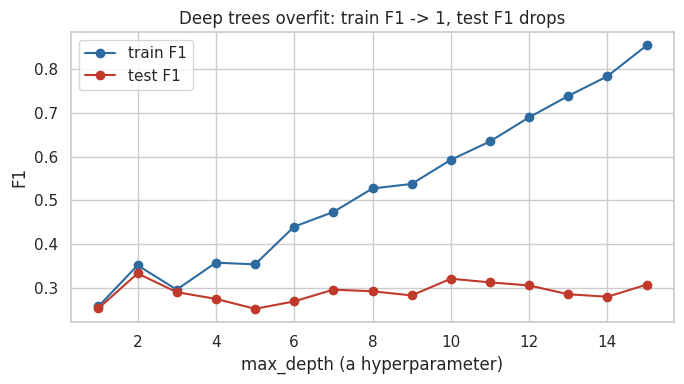

In [56]:
# -----------------------------------------------------------
# 🔹 6A. A HYPERPARAMETER (tree depth) DRIVES OVER/UNDERFIT
# -----------------------------------------------------------
depths = range(1, 16)
tr, te = [], []
for d in depths:
    p = Pipeline([('prep', pre), ('model', DecisionTreeClassifier(
        max_depth=d, class_weight='balanced', random_state=0))]).fit(X_train, y_train)
    tr.append(f1_score(y_train, p.predict(X_train)))
    te.append(f1_score(y_test, p.predict(X_test)))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(depths), tr, 'o-', label='train F1', color='#2D6A9F')
ax.plot(list(depths), te, 'o-', label='test F1', color='#C0392B')
ax.set_xlabel('max_depth (a hyperparameter)'); ax.set_ylabel('F1'); ax.legend()
ax.set_title('Deep trees overfit: train F1 -> 1, test F1 drops'); plt.tight_layout(); plt.show()


 EXERCISE 6 — Pick the depth
Find the max_depth with the highest test F1.
In a comment, distinguish a parameter (learned in fit) from a hyperparameter (you chose max_depth), using this tree as the example.

In [58]:
# 1. best max_depth by test F1
best_depth_index = te.index(max(te))
best_max_depth = depths[best_depth_index]
best_test_f1 = max(te)

print(f"Best max_depth: {best_max_depth}")
print(f"Highest test F1 at this depth: {best_test_f1:.3f}")

# 2. parameter vs hyperparameter here: ...   (comment)
# In the Decision Tree model, `max_depth` is a hyperparameter. It's a setting that you, the data scientist, choose *before* training the model (e.g., in the `DecisionTreeClassifier` constructor).
# Parameters, on the other hand, are values learned by the model *during* the `fit()` process from the training data. For a Decision Tree, examples of parameters would be the specific split points (thresholds) at each node and the feature chosen for each split. These are internal to the tree structure and are determined by the algorithm based on the data, not set manually beforehand.

Best max_depth: 2
Highest test F1 at this depth: 0.333
